## We present result on natural images including 

1.horizontal connection visualualization

2.denoising result of natural images, compare to sparse coding

In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

from recurrent_diffusion_pkg.utils import (
    load_lit_model,
    fit_decoder_level_gabor_bank,
    plot_gabor_needles,
    plot_original_vs_reconstructed_gabor,
    build_loaders_from_config,
    vis_patches
)
# natural scene model
# BASE_DIR = Path("/home/zeyuy/recurrent_diffusion_minimal/pretrained_model/scaling-VH-new-2/00005_simple_sheet7_simple_control_small_noise")
# larger face model
BASE_DIR = Path("/home/zeyuy/recurrent_diffusion_minimal/pretrained_model/scaling-new-face/00026_simplify_layer1_neural_sheet7_intra_film_scalar_mul_ff_scale_large_large_noise_simple_control")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

config, lit_model = load_lit_model(BASE_DIR, device=DEVICE, ckpt_name=None)
net = lit_model.ema_model.eval()

print("Loaded:", BASE_DIR)
print("n_levels:", net.n_levels)

<class 'recurrent_diffusion_pkg.model.neural_sheet7'>
EMA <class 'recurrent_diffusion_pkg.model.neural_sheet7'>
Loaded: /home/zeyuy/recurrent_diffusion_minimal/pretrained_model/scaling-new-face/00026_simplify_layer1_neural_sheet7_intra_film_scalar_mul_ff_scale_large_large_noise_simple_control
n_levels: 4


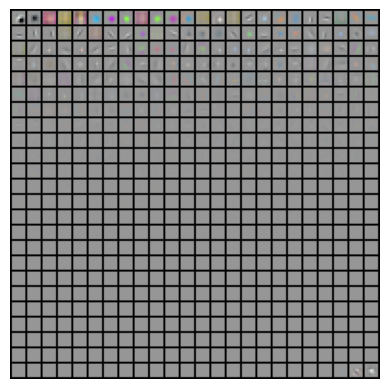

In [15]:
# visualize all the ff neurons
# visualize neurons all
w_v_all_ls = []
w_g_all_ls = []
for level in range(net.n_levels):
    net.levels[level].reset_wnorm()
    w_v = net.levels[level].encoder_node.encoder.weight.data.detach()
    w_g = net.levels[level].encoder_node.encoder.weight_g.data.flatten().detach()
    w_v_all_ls.append(w_v)
    w_g_all_ls.append(w_g)
w_v_all = torch.cat(w_v_all_ls)
w_g_all = torch.cat(w_g_all_ls)

w_g_all_sort_v,w_g_all_sort_idx = w_g_all.sort(descending=True)
vis_patches(w_v_all[w_g_all_sort_idx].flatten(2).cpu(),name = 'ff_raw_weight_face')

In [11]:


import torch
import torch.nn.functional as F

w_v_all_ls = []
w_g_all_ls = []

# Calculate the effective receptive field size of the highest level
base_kernel_size = 7
max_scale_factor = 2 ** (net.n_levels - 1)
target_size = base_kernel_size * max_scale_factor 

for level in range(net.n_levels):
    net.levels[level].reset_wnorm()
    
    w_v = net.levels[level].encoder_node.encoder.weight.data.detach()
    w_g = net.levels[level].encoder_node.encoder.weight_g.data.flatten().detach()
    
    level_scale = 2 ** level
    
    if level_scale > 1:
        w_v = F.interpolate(w_v, scale_factor=level_scale, mode='bicubic', align_corners=False)
        
    current_size = w_v.shape[-1]
    
    # --- CORRECTED PADDING LOGIC ---
    if current_size < target_size:
        pad_total = target_size - current_size
        pad_before = pad_total // 2
        pad_after = pad_total - pad_before
        
        # F.pad expects: (left, right, top, bottom)
        w_v = F.pad(w_v, (pad_before, pad_after, pad_before, pad_after), mode='constant', value=0)

    w_v_all_ls.append(w_v)
    w_g_all_ls.append(w_g)

# Now all filters are guaranteed to be exactly (target_size x target_size)
w_v_all = torch.cat(w_v_all_ls, dim=0)
w_g_all = torch.cat(w_g_all_ls, dim=0)

w_g_all_sort_v, w_g_all_sort_idx = w_g_all.sort(descending=True)
vis_patches(w_v_all[w_g_all_sort_idx][:200].flatten(2).cpu(),figsize = (20,20),name = 'ff_weight_face_top_200')